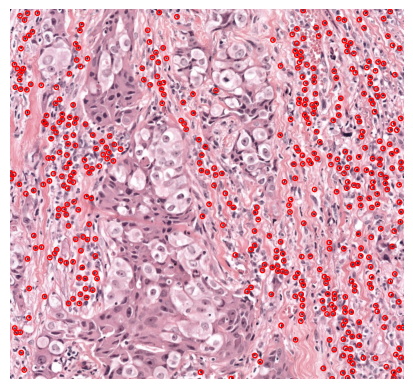

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fill_holes(gray):
    flood_filled = gray.copy()
    h, w = gray.shape[:2]
    mask = np.zeros((h+2, w+2), np.uint8)

    # Flood fill from point (0, 0)
    cv2.floodFill(flood_filled, mask, (0, 0), 255)

    # Invert flood-filled image
    flood_filled_inv = cv2.bitwise_not(flood_filled)

    # Combine with original to fill holes
    filled = gray | flood_filled_inv
    return filled

def remove_noise(gray):
    # Find connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(gray, connectivity=8)
    filtered_img = np.zeros_like(gray)
    min_area = 20
    max_area = 80
    for i in range(1, num_labels):  # skip background (label 0)
        if stats[i, cv2.CC_STAT_AREA] >= min_area and stats[i, cv2.CC_STAT_AREA] <= max_area:
            filtered_img[labels == i] = 255
    return filtered_img

# Load image in color
image = cv2.imread(r'wsi.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tils = np.load(r'wsi_tils.npy')
plt.figure()
plt.imshow(image)
if len(tils)>0:
    plt.scatter(tils[:,0], tils[:,1], facecolors = 'none', edgecolors = 'r', s = 10)
plt.axis('off')
plt.show()

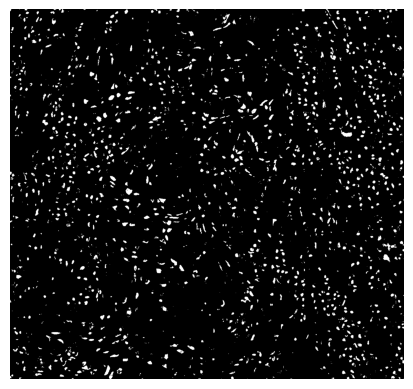

In [2]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

gray = cv2.inRange(gray, 0,100)
plt.figure()
plt.imshow(gray, cmap = 'gray')
plt.axis('off')
plt.show()

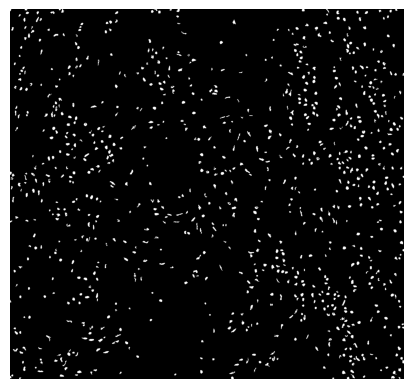

In [3]:
gray = remove_noise(gray)
plt.figure()
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

# gray = fill_holes(gray)
# plt.subplot(1, 1, 1)
# plt.imshow(gray, cmap='gray')
# plt.axis("off")
# plt.show()

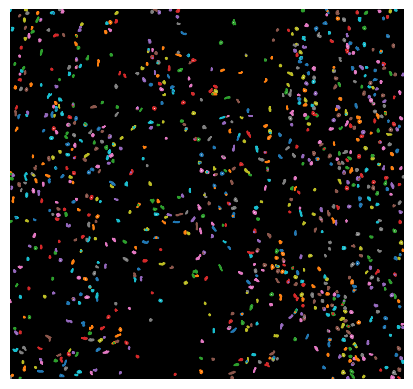

In [4]:
# Find Contours
contours, _= cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
contours = [i for i in contours if i.shape[0]>3] # to include counters with more than 3 edges
contours = [i[:,0,:] for i in contours]
contours = [np.vstack([i, i[0,:]]) for i in contours]     

plt.figure()
plt.imshow(gray, cmap = 'gray')
if len(contours)>0:
    for c in contours:
        plt.plot(c[:,0],c[:,1], linewidth = 1)
plt.axis('off')
plt.show()

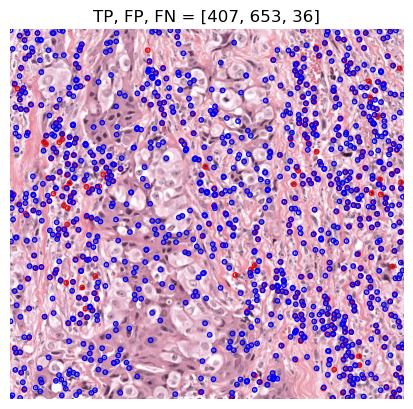

Sen = 0.9187358916478555
FPs = 653


In [5]:
predicted_tils = np.array([np.mean(i, axis = 0) for i in contours])

from count_tp_fp_fn import count_tp_fp_fn
tp_fp_fn = count_tp_fp_fn(tils, predicted_tils, 8, 1)

plt.figure()
plt.imshow(image)
if len(tils)>0:
    plt.scatter(tils[:,0], tils[:,1], facecolors = 'none', edgecolors = 'r', s = 10)
if len(predicted_tils)>0:
    plt.scatter(predicted_tils[:,0], predicted_tils[:,1], facecolors = 'none', edgecolors = 'b', s = 10)
plt.title('TP, FP, FN = '+str(tp_fp_fn))
plt.axis('off')
plt.show()

print('Sen = '+str(tp_fp_fn[0]/(tp_fp_fn[0]+tp_fp_fn[2])))
print('FPs = '+str(tp_fp_fn[1]))